# XGBoost Rheology Model Comparison Workflow

**Objective:** Compare five rheology formulations (5-parameter CY, Power Law, Sisko, Williamson, constrained CY) using XGBoost regression with Optuna hyperparameter tuning.

**Key Metrics:** R², MSE, RMSE evaluated on a shared train/test split.

**Deliverables:** Clean comparison tables and visualizations ranked by performance.

## Section 1: Set Up Environment and Dependencies

In [2]:
# Verify environment
import sys
print(f"Python: {sys.version}")
print(f"Executable: {sys.executable}")

Python: 3.11.14 | packaged by conda-forge | (main, Jan 27 2026, 00:01:01) [Clang 19.1.7 ]
Executable: /Users/jaidonfroggatt-morton/miniforge3/envs/msc-dissertation-mots1/bin/python


In [3]:
# Import core dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Import ML libraries
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import least_squares
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler

print(f"xgboost: {xgb.__version__}")
print(f"optuna: {optuna.__version__}")
print("Environment ready!")

xgboost: 3.2.0
optuna: 4.8.0
Environment ready!


## Section 2: Define Parameters and Runtime Configuration

In [4]:
# Configuration
CONFIG = {
    'random_seed': 42,
    'n_trials': 10,
    'test_size': 0.2,
    'viscosity_shears': np.array([1.0, 10.0, 100.0]),
    'log_numeric_features': False,
}

# Paths
BASE_PATH = Path("..")
DATA_PATH = BASE_PATH / "data" / "processed"
SPLITS_PATH = DATA_PATH / "splits"
RESULTS_PATH = DATA_PATH / "xgboost_results"

# Create results directory
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# Model specifications
MODEL_SPECS = [
    ('cy5', '5-parameter CY'),
    ('power_law', 'Power Law'),
    ('sisko', 'Sisko'),
    ('williamson', 'Williamson'),
    ('constrained_cy', 'Constrained CY'),
]

# Target mappings for each model
TARGET_COLS = {
    'cy5': ['eta_0', 'eta_inf', 'lambda_time', 'n', 'a'],
    'power_law': ['k_consistency', 'n_flow'],
    'sisko': ['eta_inf_sisko', 'k_sisko', 'n_sisko'],
    'williamson': ['eta_0', 'eta_inf', 'lambda_time', 'n_w'],
    'constrained_cy': ['eta_0', 'lambda_time', 'n'],  # Fixed: only 3 free parameters
}

print("Configuration loaded:")
print(f"  Seed: {CONFIG['random_seed']}")
print(f"  Optuna trials: {CONFIG['n_trials']}")
print(f"  Log numeric features: {CONFIG['log_numeric_features']}")
print(f"  Results path: {RESULTS_PATH}")
print(f"  Models: {len(MODEL_SPECS)}")

Configuration loaded:
  Seed: 42
  Optuna trials: 10
  Log numeric features: False
  Results path: ../data/processed/xgboost_results
  Models: 5


## Section 3: Load Data and Validate

In [5]:
# Load train/test split
train_df = pd.read_csv(SPLITS_PATH / "expanded_train.csv")
test_df = pd.read_csv(SPLITS_PATH / "expanded_test.csv")

print(f"Train set: {train_df.shape}")
print(f"Test set: {test_df.shape}")
print(f"\nTrain columns: {train_df.columns.tolist()[:10]}...")
print(f"\nNo overlap check:")
train_mixes = set(train_df['Composite_Mix_ID'].unique())
test_mixes = set(test_df['Composite_Mix_ID'].unique())
overlap = train_mixes & test_mixes
print(f"  Overlapping mix IDs: {len(overlap)} (expected 0)")
assert len(overlap) == 0, "Leakage detected!"

Train set: (136, 12)
Test set: (42, 12)

Train columns: ['Dispersent_Type', 'Solid_Content_pct', 'Solid_Additive_pct', 'Viscosity_at_shear_rate_1_1/s', 'Viscosity_at_shear_rate_10_1/s', 'Viscosity_at_shear_rate_100_1/s', 'Source_Batch', 'Composite_Mix_ID', 'NMC_pct', 'C65_pct']...

No overlap check:
  Overlapping mix IDs: 0 (expected 0)


## Section 4: Physics Model Fitting Functions

In [6]:
def fit_cy5_row(viscosities, shear_rates):
    '''5-parameter Carreau-Yasuda fit.'''
    def residuals(p, visc, sr):
        eta_0, eta_inf, lambda_time, n, a = p
        if eta_0 <= eta_inf or lambda_time <= 0 or n <= 0 or a <= 0:
            return np.full_like(visc, 1e10)
        eta_fit = eta_inf + (eta_0 - eta_inf) * (1 + (lambda_time * sr) ** a) ** ((n - 1) / a)
        return np.log(eta_fit) - np.log(visc)
    
    p0 = [10.0, 0.01, 0.1, 0.5, 1.0]
    bounds = ([0.1, 0, 0.01, 0.1, 0.1], [1000, 10, 10, 1.0, 2.0])
    try:
        res = least_squares(residuals, p0, args=(viscosities, shear_rates), bounds=bounds, max_nfev=10000)
        return res.x if res.success else p0
    except:
        return p0

def fit_power_law_row(viscosities, shear_rates):
    '''Power-law fit: η = K * γ̇^(n-1).'''
    def residuals(p, visc, sr):
        k, n = p
        if k <= 0 or n <= 0:
            return np.full_like(visc, 1e10)
        eta_fit = k * sr ** (n - 1)
        return np.log(eta_fit) - np.log(visc)
    
    p0 = [1.0, 0.5]
    bounds = ([0.001, 0.01], [1000, 2.0])
    try:
        res = least_squares(residuals, p0, args=(viscosities, shear_rates), bounds=bounds, max_nfev=10000)
        return res.x if res.success else p0
    except:
        return p0

def fit_sisko_row(viscosities, shear_rates):
    '''Sisko fit: η = η_∞ + K * γ̇^(n-1).'''
    def residuals(p, visc, sr):
        eta_inf, k, n = p
        if eta_inf < 0 or k <= 0 or n <= 0:
            return np.full_like(visc, 1e10)
        eta_fit = eta_inf + k * sr ** (n - 1)
        return np.log(eta_fit) - np.log(visc)
    
    p0 = [0.01, 1.0, 0.5]
    bounds = ([0, 0.001, 0.01], [1, 1000, 2])
    try:
        res = least_squares(residuals, p0, args=(viscosities, shear_rates), bounds=bounds, max_nfev=10000)
        return res.x if res.success else p0
    except:
        return p0

def fit_williamson_row(viscosities, shear_rates):
    '''Williamson fit.'''
    def residuals(p, visc, sr):
        eta_0, eta_inf, lambda_time, n_w = p
        if eta_0 <= eta_inf or lambda_time <= 0 or n_w <= 0:
            return np.full_like(visc, 1e10)
        eta_fit = eta_inf + (eta_0 - eta_inf) / (1 + (lambda_time * sr) ** n_w)
        return np.log(eta_fit) - np.log(visc)
    
    p0 = [10.0, 0.01, 0.1, 0.5]
    bounds = ([0.1, 0, 0.01, 0.1], [1000, 10, 10, 1.0])
    try:
        res = least_squares(residuals, p0, args=(viscosities, shear_rates), bounds=bounds, max_nfev=10000)
        return res.x if res.success else p0
    except:
        return p0

def fit_constrained_cy_row(viscosities, shear_rates):
    '''Constrained Carreau-Yasuda (eta_inf=0.01, a=2.0 fixed).'''
    def residuals(p, visc, sr):
        eta_0, lambda_time, n = p
        eta_inf = 0.01
        a = 2.0
        if eta_0 <= eta_inf or lambda_time <= 0 or n <= 0:
            return np.full_like(visc, 1e10)
        eta_fit = eta_inf + (eta_0 - eta_inf) * (1 + (lambda_time * sr) ** a) ** ((n - 1) / a)
        return np.log(eta_fit) - np.log(visc)
    
    p0 = [10.0, 0.1, 0.5]
    bounds = ([0.1, 0.01, 0.1], [1000, 10, 1.0])
    try:
        res = least_squares(residuals, p0, args=(viscosities, shear_rates), bounds=bounds, max_nfev=10000)
        return res.x if res.success else p0
    except:
        return p0

print("Physics model fitters defined (5 models).")

Physics model fitters defined (5 models).


In [7]:
def build_physics_dataset(df, model_name):
    '''Fit physics parameters for each row in the dataset.'''
    fitter_map = {
        'cy5': fit_cy5_row,
        'power_law': fit_power_law_row,
        'sisko': fit_sisko_row,
        'williamson': fit_williamson_row,
        'constrained_cy': fit_constrained_cy_row,
    }
    
    fitter = fitter_map[model_name]
    target_cols = TARGET_COLS[model_name]
    
    results = []
    for _, row in df.iterrows():
        visc = np.array([row['Viscosity_at_shear_rate_1_1/s'], row['Viscosity_at_shear_rate_10_1/s'], row['Viscosity_at_shear_rate_100_1/s']])
        params = fitter(visc, CONFIG['viscosity_shears'])
        result_row = {col_name: row[col_name] for col_name in df.columns}
        for i, param_name in enumerate(target_cols):
            result_row[param_name] = params[i]
        results.append(result_row)
    
    physics_df = pd.DataFrame(results)
    physics_df.attrs['target_cols'] = target_cols
    return physics_df

print("Physics dataset builder defined.")

Physics dataset builder defined.


## Section 5: Build Physics Datasets for Train and Test

In [8]:
# Build physics datasets for all models
physics_datasets = {}

for model_key, display_name in MODEL_SPECS:
    print(f"Fitting {display_name}...", end=" ")
    train_physics = build_physics_dataset(train_df, model_key)
    test_physics = build_physics_dataset(test_df, model_key)
    physics_datasets[model_key] = {
        'train': train_physics,
        'test': test_physics,
        'display_name': display_name,
    }
    print(f"({len(train_physics.attrs['target_cols'])} targets)")

print("\nAll physics datasets built.")

Fitting 5-parameter CY... (5 targets)
Fitting Power Law... (2 targets)
Fitting Sisko... (3 targets)
Fitting Williamson... (4 targets)
Fitting Constrained CY... (3 targets)

All physics datasets built.


In [9]:
# Inspect features after viscosity removal
print("\n" + "="*70)
print("FEATURE INSPECTION: What remains after viscosity removal")
print("="*70)

# Use the first model (cy5) as example
sample_model_key = 'cy5'
train_physics = physics_datasets[sample_model_key]['train']
target_cols_list = train_physics.attrs['target_cols']

# Replicate the feature selection from tune_and_evaluate_xgb()
feature_cols = [col for col in train_physics.columns 
                if col not in target_cols_list 
                and not col.startswith('Viscosity_at_shear_rate')]

print(f"\nModel: {sample_model_key.upper()}")
print(f"Target columns ({len(target_cols_list)}): {target_cols_list}")
print(f"\nAvailable features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Check data types
print("\nFeature types:")
for col in feature_cols:
    dtype = train_physics[col].dtype
    if dtype == 'object':
        n_unique = train_physics[col].nunique()
        print(f"  {col}: {dtype} ({n_unique} unique values)")
    else:
        min_val = train_physics[col].min()
        max_val = train_physics[col].max()
        print(f"  {col}: {dtype} (range: {min_val:.4f} - {max_val:.4f})")


FEATURE INSPECTION: What remains after viscosity removal

Model: CY5
Target columns (5): ['eta_0', 'eta_inf', 'lambda_time', 'n', 'a']

Available features (9):
  1. Dispersent_Type
  2. Solid_Content_pct
  3. Solid_Additive_pct
  4. Source_Batch
  5. Composite_Mix_ID
  6. NMC_pct
  7. C65_pct
  8. KS6L_pct
  9. PVDF_pct

Feature types:
  Dispersent_Type: object (4 unique values)
  Solid_Content_pct: float64 (range: 69.0000 - 77.0000)
  Solid_Additive_pct: float64 (range: 0.0000 - 0.5000)
  Source_Batch: object (2 unique values)
  Composite_Mix_ID: object (54 unique values)
  NMC_pct: float64 (range: 96.0000 - 97.0000)
  C65_pct: float64 (range: 0.0000 - 2.0000)
  KS6L_pct: float64 (range: 0.0000 - 2.0000)
  PVDF_pct: float64 (range: 1.5000 - 2.0000)


## Section 5B: Physics Model Fit Visualizations

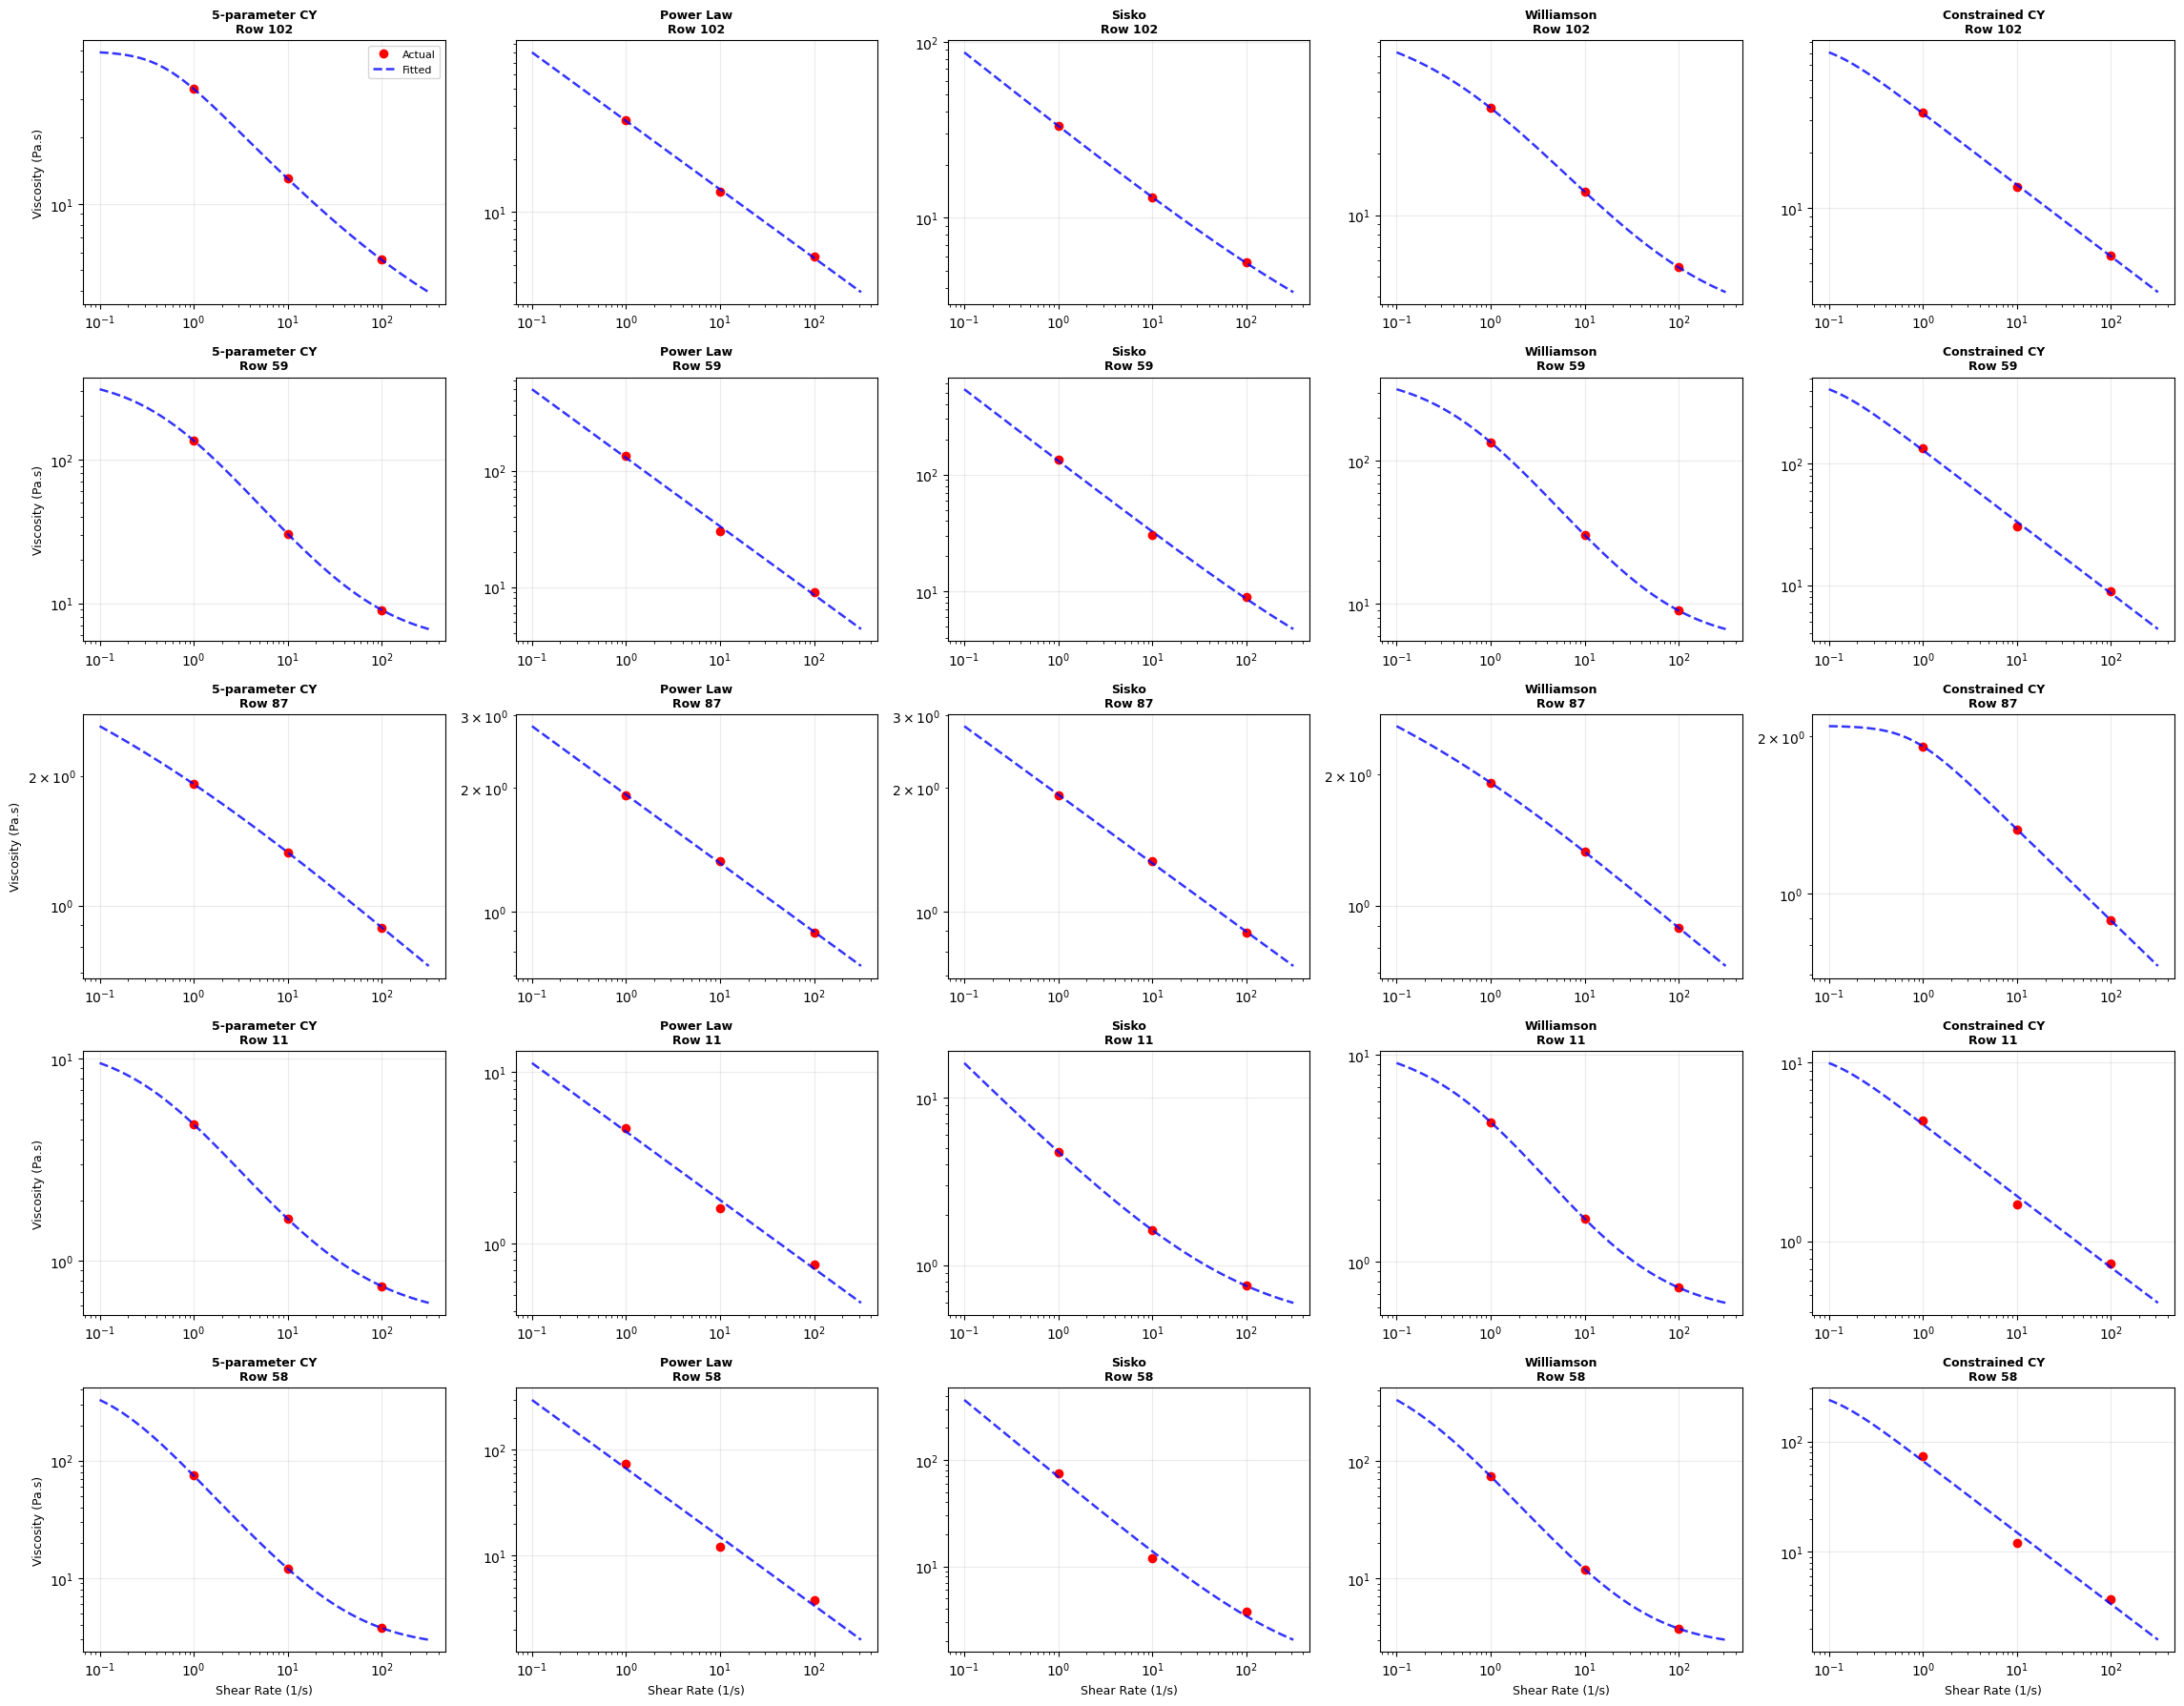

Random sample rows used: [102, 59, 87, 11, 58]
Physics model fits saved to: ../data/processed/xgboost_results/physics_model_fits_random_25.png


In [10]:
# Visualize physics model fits for random sample rows (5 rows x 5 models = 25 plots)
n_random_rows = min(5, len(train_df))
rng = np.random.default_rng(CONFIG['random_seed'])
sample_indices = rng.choice(train_df.index.to_numpy(), size=n_random_rows, replace=False)

fitter_map = {
    'cy5': fit_cy5_row,
    'power_law': fit_power_law_row,
    'sisko': fit_sisko_row,
    'williamson': fit_williamson_row,
    'constrained_cy': fit_constrained_cy_row,
}

n_models = len(MODEL_SPECS)
fig, axes = plt.subplots(
    n_random_rows,
    n_models,
    figsize=(4.6 * n_models, 3.6 * n_random_rows),
    squeeze=False,
)

sr_range = np.logspace(-1, 2.5, 100)

for row_pos, sample_idx in enumerate(sample_indices):
    row_data = train_df.loc[sample_idx]
    actual_visc = np.array([
        row_data['Viscosity_at_shear_rate_1_1/s'],
        row_data['Viscosity_at_shear_rate_10_1/s'],
        row_data['Viscosity_at_shear_rate_100_1/s'],
    ])

    for col_pos, (model_key, display_name) in enumerate(MODEL_SPECS):
        ax = axes[row_pos, col_pos]

        # Plot measured points
        ax.loglog(
            CONFIG['viscosity_shears'],
            actual_visc,
            'o',
            markersize=6,
            label='Actual',
            color='red',
        )

        # Fit selected model to this row
        params = fitter_map[model_key](actual_visc, CONFIG['viscosity_shears'])

        # Generate fitted curve
        if model_key == 'cy5':
            eta_0, eta_inf, lambda_time, n, a = params
            fitted_visc = eta_inf + (eta_0 - eta_inf) * (1 + (lambda_time * sr_range) ** a) ** ((n - 1) / a)
        elif model_key == 'power_law':
            k, n = params
            fitted_visc = k * sr_range ** (n - 1)
        elif model_key == 'sisko':
            eta_inf, k, n = params
            fitted_visc = eta_inf + k * sr_range ** (n - 1)
        elif model_key == 'williamson':
            eta_0, eta_inf, lambda_time, n_w = params
            fitted_visc = eta_inf + (eta_0 - eta_inf) / (1 + (lambda_time * sr_range) ** n_w)
        else:  # constrained_cy
            eta_0, lambda_time, n = params
            eta_inf, a = 0.01, 2.0
            fitted_visc = eta_inf + (eta_0 - eta_inf) * (1 + (lambda_time * sr_range) ** a) ** ((n - 1) / a)

        ax.loglog(
            sr_range,
            fitted_visc,
            '--',
            linewidth=1.8,
            label='Fitted',
            color='blue',
            alpha=0.8,
        )

        ax.set_title(f'{display_name}\nRow {sample_idx}', fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.25)

        if row_pos == n_random_rows - 1:
            ax.set_xlabel('Shear Rate (1/s)', fontsize=9)
        if col_pos == 0:
            ax.set_ylabel('Viscosity (Pa.s)', fontsize=9)

        if row_pos == 0 and col_pos == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'physics_model_fits_random_25.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Random sample rows used: {sample_indices.tolist()}')
print(f"Physics model fits saved to: {RESULTS_PATH / 'physics_model_fits_random_25.png'}")

## Section 6: XGBoost Pipeline and Optuna Tuning Functions

In [11]:
def make_preprocessor(X_df, log_numeric_features=False):
    '''Create preprocessing pipeline.'''
    categorical_cols = []
    numeric_cols = []
    
    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)
    
    transformers = []
    if categorical_cols:
        transformers.append(
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
        )
    if numeric_cols:
        numeric_steps = []
        numeric_steps.append(('impute', SimpleImputer(strategy='median')))
        if log_numeric_features:
            numeric_steps.append(('log1p', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')))
        transformers.append(
            ('num', Pipeline(numeric_steps), numeric_cols)
        )
    
    return ColumnTransformer(transformers=transformers, remainder='drop')

def r2_mse_rmse(y_true, y_pred):
    '''Compute metrics.'''
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return r2, mse, rmse

print("Pipeline utilities defined.")

Pipeline utilities defined.


In [12]:
def make_xgb_objective(X_train, y_train, seed):
    '''Create Optuna objective function for XGBoost.'''
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
            'random_state': seed,
            'n_estimators': 100,
            'verbosity': 0,
        }
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_train[:int(0.8*len(X_train))], y_train[:int(0.8*len(y_train))],
                 eval_set=[(X_train[int(0.8*len(X_train)):], y_train[int(0.8*len(y_train)):])])
        
        val_pred = model.predict(X_train[int(0.8*len(X_train)):])
        val_r2, _, _ = r2_mse_rmse(y_train[int(0.8*len(y_train)):], val_pred)
        
        return val_r2
    
    return objective

print("Optuna objective function defined.")

Optuna objective function defined.


In [13]:
def engineer_composition_features(X_df):
    '''Create physically motivated composition features for rheology prediction.

    The base task is intentionally composition-only: we want the model to infer
    rheology parameters from formulation rather than from measured viscosity.

    These engineered features encode simple slurry physics that are not explicit
    in the raw percentages:
    - loading balances between active material, conductive additives, and binder
    - particle-to-binder ratios that influence network formation
    - interactions with overall solids loading, which is usually the dominant
      driver of crowding, structure build-up, and shear thinning
    '''
    engineered = X_df.copy()
    eps = 1e-6

    '''Keep the raw composition columns so the model still has access to the
    original formulation values.'''
    if "C65_pct" in engineered.columns and "KS6L_pct" in engineered.columns:
        '''Conductive additives often act together as a percolating network, so
        their combined loading is a useful summary of conductive structure.'''
        engineered["conductive_total"] = engineered["C65_pct"] + engineered["KS6L_pct"]
    else:
        engineered["conductive_total"] = np.nan

    if "NMC_pct" in engineered.columns and "C65_pct" in engineered.columns and "KS6L_pct" in engineered.columns:
        '''Total solid loading excluding binder gives a compact measure of how
        crowded the suspension is before the binder contribution is considered.'''
        engineered["nonbinder_total"] = engineered["NMC_pct"] + engineered["C65_pct"] + engineered["KS6L_pct"]
    else:
        engineered["nonbinder_total"] = np.nan

    if "PVDF_pct" in engineered.columns:
        '''Binder fraction is kept as-is because it controls particle cohesion,
        film formation, and the stability of the slurry microstructure.'''
        engineered["binder_share"] = engineered["PVDF_pct"]

    '''Ratios capture competition between crowding and binding. In rheology,
    these balances are often more informative than the raw percentages.'''
    if "NMC_pct" in engineered.columns and "PVDF_pct" in engineered.columns:
        engineered["NMC_to_binder"] = engineered["NMC_pct"] / (engineered["PVDF_pct"] + eps)
    if "conductive_total" in engineered.columns and "PVDF_pct" in engineered.columns:
        engineered["conductive_to_binder"] = engineered["conductive_total"] / (engineered["PVDF_pct"] + eps)
    if "Solid_Content_pct" in engineered.columns and "Solid_Additive_pct" in engineered.columns:
        engineered["solid_to_additive"] = engineered["Solid_Content_pct"] / (engineered["Solid_Additive_pct"] + eps)

    '''Interactions let XGBoost represent nonlinear coupling between solids
    loading and the components that are most likely to control structure
    formation and shear thinning.'''
    if "Solid_Content_pct" in engineered.columns and "NMC_pct" in engineered.columns:
        engineered["solid_x_nmc"] = engineered["Solid_Content_pct"] * engineered["NMC_pct"]
    if "Solid_Content_pct" in engineered.columns and "PVDF_pct" in engineered.columns:
        engineered["solid_x_pvdf"] = engineered["Solid_Content_pct"] * engineered["PVDF_pct"]
    if "Solid_Content_pct" in engineered.columns and "conductive_total" in engineered.columns:
        engineered["solid_x_conductive"] = engineered["Solid_Content_pct"] * engineered["conductive_total"]

    '''Small additive fractions can be highly skewed, so adding a stabilized
    log transform gives the model another view of subtle formulation changes.'''
    for col in ["Solid_Additive_pct", "C65_pct", "KS6L_pct"]:
        if col in engineered.columns:
            engineered[f"log1p_{col}"] = np.log1p(engineered[col])

    return engineered

In [14]:
def tune_and_evaluate_xgb(physics_train, physics_test, target_col, seed, n_trials, log_numeric_features=False):
    '''Full XGBoost pipeline: tune, train, evaluate.'''
    target_cols_list = physics_train.attrs['target_cols']

    '''Keep this task composition-only: use formulation variables, not viscosity
    measurements and not row identifiers. The goal is to learn how slurry
    composition maps to fitted rheology parameters.'''
    composition_cols = [
        "Dispersent_Type",
        "Solid_Content_pct",
        "Solid_Additive_pct",
        "NMC_pct",
        "C65_pct",
        "KS6L_pct",
        "PVDF_pct",
    ]
    feature_cols = [col for col in composition_cols if col in physics_train.columns]

    X_train_raw = physics_train[feature_cols].copy()
    y_train = physics_train[target_col].copy()
    X_test_raw = physics_test[feature_cols].copy()
    y_test = physics_test[target_col].copy()

    '''Feature engineering adds physics-inspired summaries of the formulation.
    These are still composition-only, but they encode particle loading,
    binder balance, conductive network strength, and nonlinear interactions
    that the raw percentages may not express directly.'''
    X_train = engineer_composition_features(X_train_raw)
    X_test = engineer_composition_features(X_test_raw)

    '''Preprocess.
    Categorical columns are one-hot encoded; numeric columns are imputed and,
    optionally, log-transformed. This preserves the meaning of the engineered
    features while making them usable by XGBoost.'''
    preprocessor = make_preprocessor(X_train, log_numeric_features=log_numeric_features)
    X_train_proc = preprocessor.fit_transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    '''Tune with Optuna.'''
    sampler = TPESampler(seed=seed)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    objective = make_xgb_objective(X_train_proc, y_train, seed)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_params.update({'random_state': seed, 'n_estimators': 100, 'verbosity': 0})

    '''Train final model.'''
    final_model = xgb.XGBRegressor(**best_params)
    final_model.fit(X_train_proc, y_train, verbose=False)

    '''Evaluate.'''
    y_train_pred = final_model.predict(X_train_proc)
    y_test_pred = final_model.predict(X_test_proc)

    train_r2, train_mse, train_rmse = r2_mse_rmse(y_train, y_train_pred)
    test_r2, test_mse, test_rmse = r2_mse_rmse(y_test, y_test_pred)

    result = {
        'target': target_col,
        'train_r2': train_r2,
        'train_mse': train_mse,
        'train_rmse': train_rmse,
        'test_r2': test_r2,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'best_trial': study.best_trial.number,
    }

    predictions = pd.DataFrame({
        'target': target_col,
        'y_true': y_test,
        'y_pred': y_test_pred,
    })

    return result, predictions, y_train_pred

print("XGBoost pipeline function defined.")

XGBoost pipeline function defined.


## Section 7: Run Full Comparison Across All Models and Targets

In [15]:
%%capture
# Run full comparison
all_results = []
all_predictions = []
physics_summaries = []

for model_key, display_name in MODEL_SPECS:
    print(f"\n{'='*60}")
    print(f"Model: {display_name}")
    print(f"{'='*60}")
    
    train_physics = physics_datasets[model_key]['train']
    test_physics = physics_datasets[model_key]['test']
    target_cols_list = train_physics.attrs['target_cols']
    
    model_results = []
    
    for target_col in target_cols_list:
        result, pred_df, train_pred = tune_and_evaluate_xgb(
            physics_train=train_physics,
            physics_test=test_physics,
            target_col=target_col,
            seed=CONFIG['random_seed'],
            n_trials=CONFIG['n_trials'],
            log_numeric_features=CONFIG['log_numeric_features']
        )
        
        result['model_name'] = display_name
        result['model_key'] = model_key
        result['log_numeric_features'] = CONFIG['log_numeric_features']
        all_results.append(result)
        model_results.append(result)
        
        pred_df['model_name'] = display_name
        pred_df['log_numeric_features'] = CONFIG['log_numeric_features']
        all_predictions.append(pred_df)
        
        print(f"  {target_col:20s} | R²_train: {result['train_r2']:7.4f} | R²_test: {result['test_r2']:7.4f} | MSE_test: {result['test_mse']:10.2f}")
    
    # Model summary
    mean_train_r2 = np.mean([r['train_r2'] for r in model_results])
    mean_test_r2 = np.mean([r['test_r2'] for r in model_results])
    mean_test_mse = np.mean([r['test_mse'] for r in model_results])
    mean_test_rmse = np.mean([r['test_rmse'] for r in model_results])
    
    all_results.append({
        'model_name': display_name,
        'model_key': model_key,
        'target': 'MEAN',
        'log_numeric_features': CONFIG['log_numeric_features'],
        'train_r2': mean_train_r2,
        'test_r2': mean_test_r2,
        'test_mse': mean_test_mse,
        'test_rmse': mean_test_rmse,
    })

print(f"\n{'='*60}")
print("Comparison complete!")
print(f"Total targets evaluated: {len([r for r in all_results if r['target'] != 'MEAN'])}")

[I 2026-04-16 17:13:54,099] A new study created in memory with name: no-name-d645d759-f330-43d3-a0b0-88ae4a2488c6
[I 2026-04-16 17:13:54,226] Trial 0 finished with value: -0.020248994119151487 and parameters: {'max_depth': 5, 'learning_rate': 0.22648248189516842, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'lambda': 0.004207988669606638, 'alpha': 0.004207053950287938}. Best is trial 0 with value: -0.020248994119151487.
[I 2026-04-16 17:13:54,307] Trial 1 finished with value: 0.078941186486992 and parameters: {'max_depth': 3, 'learning_rate': 0.13983740016490975, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227, 'lambda': 0.0012087541473056963, 'alpha': 7.5794799533480015}. Best is trial 1 with value: 0.078941186486992.
[I 2026-04-16 17:13:54,464] Trial 2 finished with value: 0.22072741329910195 and parameters: {'max_depth': 9, 'learning_rate': 0.0033572967053517922, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.59170225492671

## Section 8: Compile Results and Create Summary Tables

In [16]:
# Create results DataFrames
results_df = pd.DataFrame(all_results)
predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()

# Model summary (sorted by mean test R²)
model_summary = results_df[results_df['target'] == 'MEAN'].copy()
model_summary = model_summary.sort_values('test_r2', ascending=False)
model_summary = model_summary[['model_name', 'train_r2', 'train_mse', 'train_rmse', 'test_r2', 'test_mse', 'test_rmse']]

print("\n" + "="*100)
print("MODEL SUMMARY (sorted by mean test R²)")
print("="*100)
print(model_summary.to_string(index=False))
print()


MODEL SUMMARY (sorted by mean test R²)
    model_name  train_r2  train_mse  train_rmse  test_r2     test_mse  test_rmse
     Power Law  0.774696        NaN         NaN 0.461717   678.715747  18.499511
    Williamson  0.490807        NaN         NaN 0.252755 20765.184912  73.154275
Constrained CY  0.631948        NaN         NaN 0.214583 16629.748172  75.667065
5-parameter CY  0.536447        NaN         NaN 0.181144 13405.502633  52.645579
         Sisko  0.666718        NaN         NaN 0.161951   525.768338  13.452262



In [17]:
# Per-target results
per_target = results_df[results_df['target'] != 'MEAN'].copy()
per_target = per_target.sort_values('test_r2', ascending=False)
per_target_display = per_target[['model_name', 'target', 'train_r2', 'test_r2', 'test_mse', 'test_rmse']]

print("\n" + "="*120)
print("PER-TARGET RESULTS (all targets, sorted by test R²)")
print("="*120)
print(per_target_display.to_string(index=False))
print()


PER-TARGET RESULTS (all targets, sorted by test R²)
    model_name        target  train_r2   test_r2     test_mse  test_rmse
5-parameter CY       eta_inf  0.852275  0.750857     0.878894   0.937494
    Williamson       eta_inf  0.930414  0.743094     1.312395   1.145598
     Power Law k_consistency  0.812793  0.616003  1357.407154  36.843007
         Sisko       k_sisko  0.806063  0.564024  1577.062279  39.712243
     Power Law        n_flow  0.736599  0.307431     0.024341   0.156015
Constrained CY             n  0.734015  0.297975     0.022714   0.150711
Constrained CY         eta_0  0.444993  0.275850 49876.836613 223.331226
5-parameter CY         eta_0  0.401749  0.222556 67019.598937 258.881438
    Williamson           n_w  0.420622  0.171061     0.037604   0.193918
    Williamson         eta_0  0.364209  0.155460 83049.817237 288.183652
5-parameter CY             n  0.334092  0.148916     0.034434   0.185565
         Sisko       n_sisko  0.407640  0.140664     0.036081   0.18994

## Section 8B: Baseline vs Log-Transformed Feature Experiment

In [18]:
%%capture
# Compare baseline vs log-transformed numeric features
EXPERIMENTS = [
    ('baseline', False),
    ('log1p_numeric', True),
]

experiment_target_results = []
experiment_model_summary = []

for experiment_name, use_log in EXPERIMENTS:
    print(f"\n{'='*70}")
    print(f"Experiment: {experiment_name} (log_numeric_features={use_log})")
    print(f"{'='*70}")
    
    for model_key, display_name in MODEL_SPECS:
        train_physics = physics_datasets[model_key]['train']
        test_physics = physics_datasets[model_key]['test']
        target_cols_list = train_physics.attrs['target_cols']
        
        model_results = []
        
        for target_col in target_cols_list:
            result, _, _ = tune_and_evaluate_xgb(
                physics_train=train_physics,
                physics_test=test_physics,
                target_col=target_col,
                seed=CONFIG['random_seed'],
                n_trials=CONFIG['n_trials'],
                log_numeric_features=use_log,
            )
            result['model_name'] = display_name
            result['model_key'] = model_key
            result['experiment'] = experiment_name
            result['log_numeric_features'] = use_log
            experiment_target_results.append(result)
            model_results.append(result)
        
        summary = {
            'experiment': experiment_name,
            'model_name': display_name,
            'log_numeric_features': use_log,
            'train_r2': np.mean([r['train_r2'] for r in model_results]),
            'test_r2': np.mean([r['test_r2'] for r in model_results]),
            'train_mse': np.mean([r['train_mse'] for r in model_results]),
            'test_mse': np.mean([r['test_mse'] for r in model_results]),
            'train_rmse': np.mean([r['train_rmse'] for r in model_results]),
            'test_rmse': np.mean([r['test_rmse'] for r in model_results]),
        }
        print(f"  {display_name:18s} | test R²={summary['test_r2']:.4f} | test RMSE={summary['test_rmse']:.4f}")
        experiment_model_summary.append(summary)

experiment_target_df = pd.DataFrame(experiment_target_results)
experiment_model_summary_df = pd.DataFrame(experiment_model_summary)
experiment_model_summary_df = experiment_model_summary_df.sort_values(['model_name', 'experiment']).reset_index(drop=True)

print("\nExperiment comparison complete.")
print(experiment_model_summary_df.to_string(index=False))

[I 2026-04-16 17:14:16,154] A new study created in memory with name: no-name-3ba5012c-2fbc-45a9-aa3d-fd662761f774
[I 2026-04-16 17:14:16,264] Trial 0 finished with value: -0.020248994119151487 and parameters: {'max_depth': 5, 'learning_rate': 0.22648248189516842, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'lambda': 0.004207988669606638, 'alpha': 0.004207053950287938}. Best is trial 0 with value: -0.020248994119151487.
[I 2026-04-16 17:14:16,344] Trial 1 finished with value: 0.078941186486992 and parameters: {'max_depth': 3, 'learning_rate': 0.13983740016490975, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227, 'lambda': 0.0012087541473056963, 'alpha': 7.5794799533480015}. Best is trial 1 with value: 0.078941186486992.
[I 2026-04-16 17:14:16,508] Trial 2 finished with value: 0.22072741329910195 and parameters: {'max_depth': 9, 'learning_rate': 0.0033572967053517922, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.59170225492671

## Section 8C: Baseline vs Log Feature Comparison Visualizations

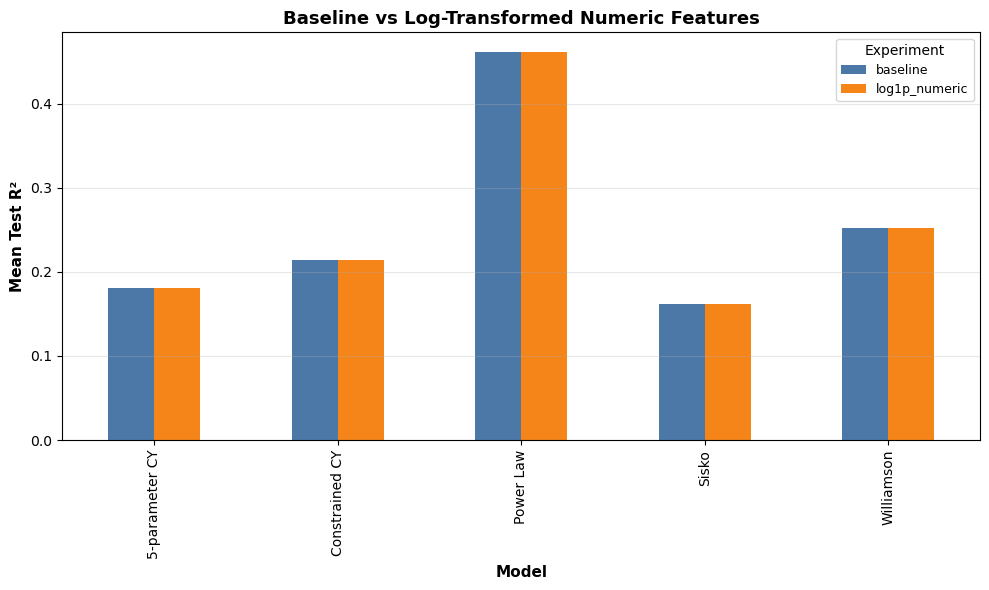

Chart saved to: ../data/processed/xgboost_results/8_baseline_vs_log_r2.png

Target-level results are available in experiment_target_df for detailed inspection.


In [19]:
# Compare experiment summaries
comparison_pivot = experiment_model_summary_df.pivot(index='model_name', columns='experiment', values='test_r2')
fig, ax = plt.subplots(figsize=(10, 6))
comparison_pivot.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518'])
ax.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_title('Baseline vs Log-Transformed Numeric Features', fontsize=13, fontweight='bold')
ax.legend(title='Experiment', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / '8_baseline_vs_log_r2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved to: {RESULTS_PATH / '8_baseline_vs_log_r2.png'}")

# View target-level gains/losses from log transform
if not experiment_target_df.empty:
    target_summary = experiment_target_df.groupby(['experiment', 'model_name', 'target'])['test_r2'].mean().reset_index()
    print("\nTarget-level results are available in experiment_target_df for detailed inspection.")

## Section 9: Save Results to CSV

In [20]:
# Save model summary
model_summary_save = model_summary.copy()
model_summary_save.to_csv(RESULTS_PATH / 'xgboost_model_summary.csv', index=False)

# Save per-target results  
per_target_save = per_target[['model_name', 'target', 'train_r2', 'train_mse', 'train_rmse', 'test_r2', 'test_mse', 'test_rmse']].copy()
per_target_save.to_csv(RESULTS_PATH / 'xgboost_per_target_results.csv', index=False)

# Save test predictions
predictions_df.to_csv(RESULTS_PATH / 'xgboost_test_predictions.csv', index=False)

print(f"Results saved to: {RESULTS_PATH}")
print(f"  ✓ xgboost_model_summary.csv")
print(f"  ✓ xgboost_per_target_results.csv")
print(f"  ✓ xgboost_test_predictions.csv")

Results saved to: ../data/processed/xgboost_results
  ✓ xgboost_model_summary.csv
  ✓ xgboost_per_target_results.csv
  ✓ xgboost_test_predictions.csv


## Section 10: Visualizations

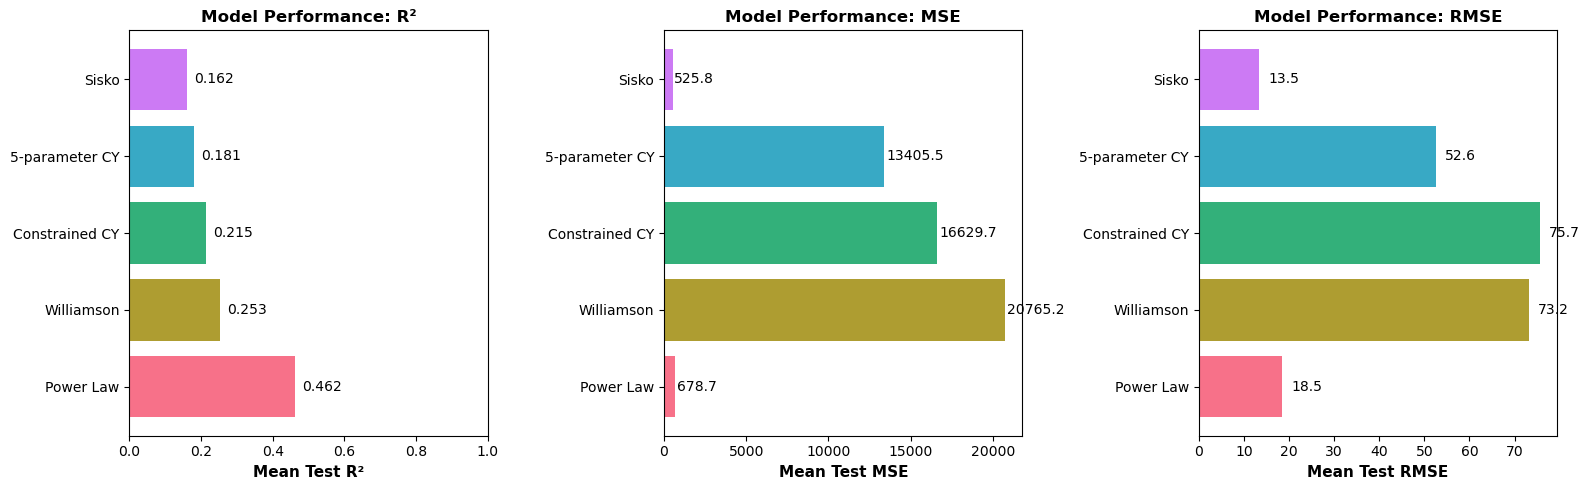

Chart 1 saved: ../data/processed/xgboost_results/1_model_comparison_charts.png


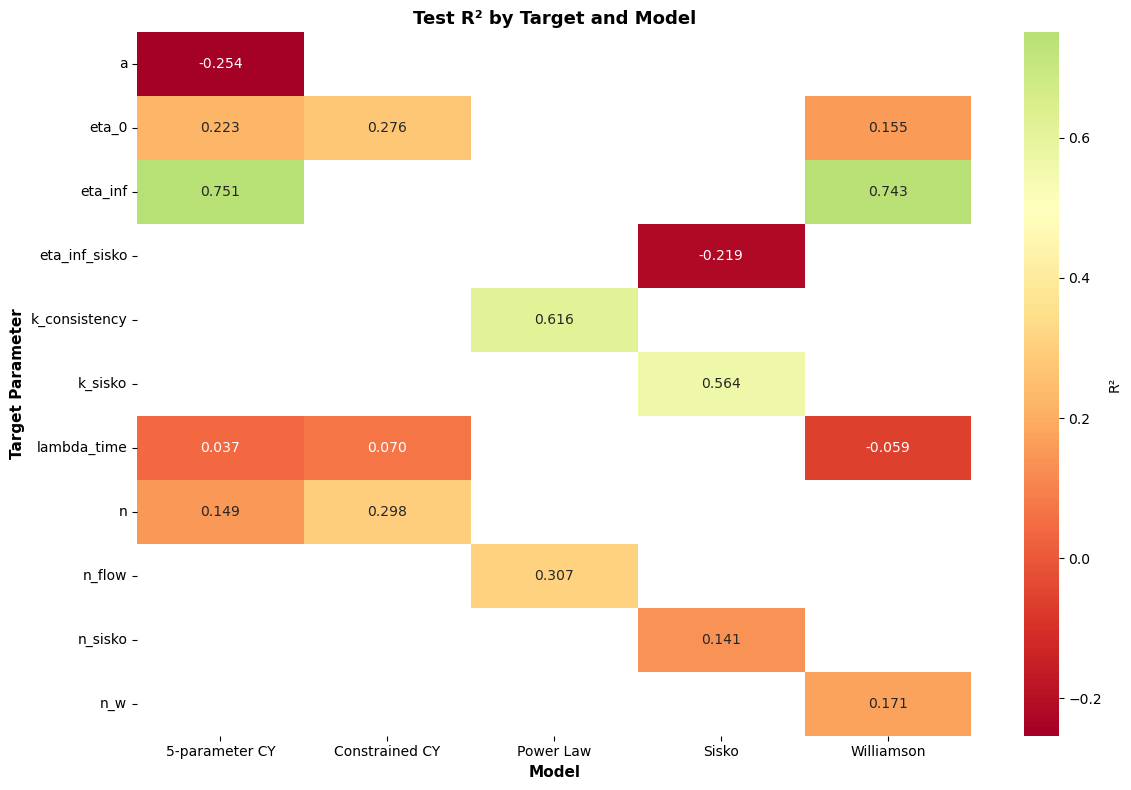

Chart 2 saved: ../data/processed/xgboost_results/2_per_target_r2_heatmap.png


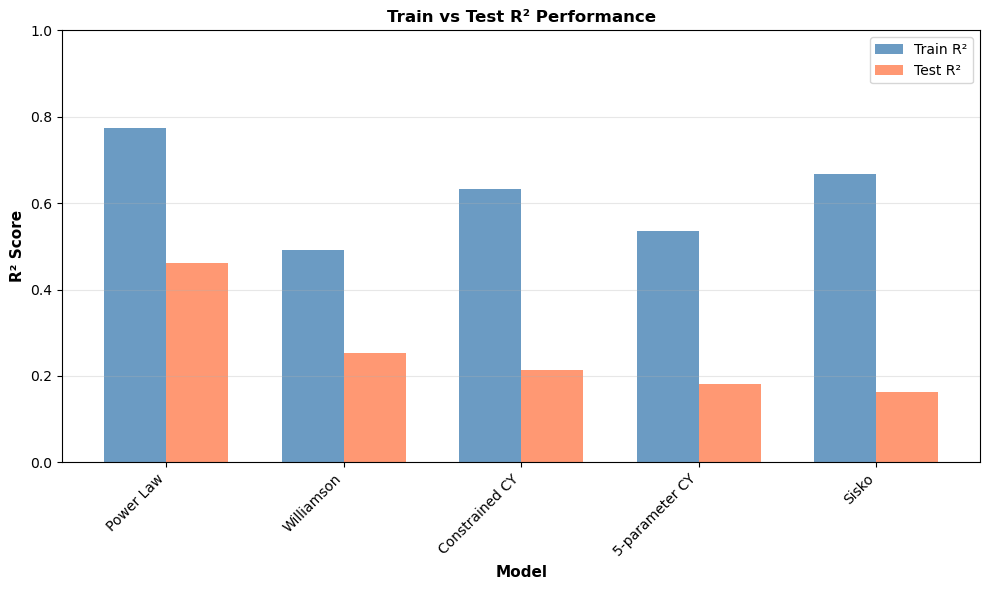

Chart 3 saved: ../data/processed/xgboost_results/3_train_vs_test_r2.png


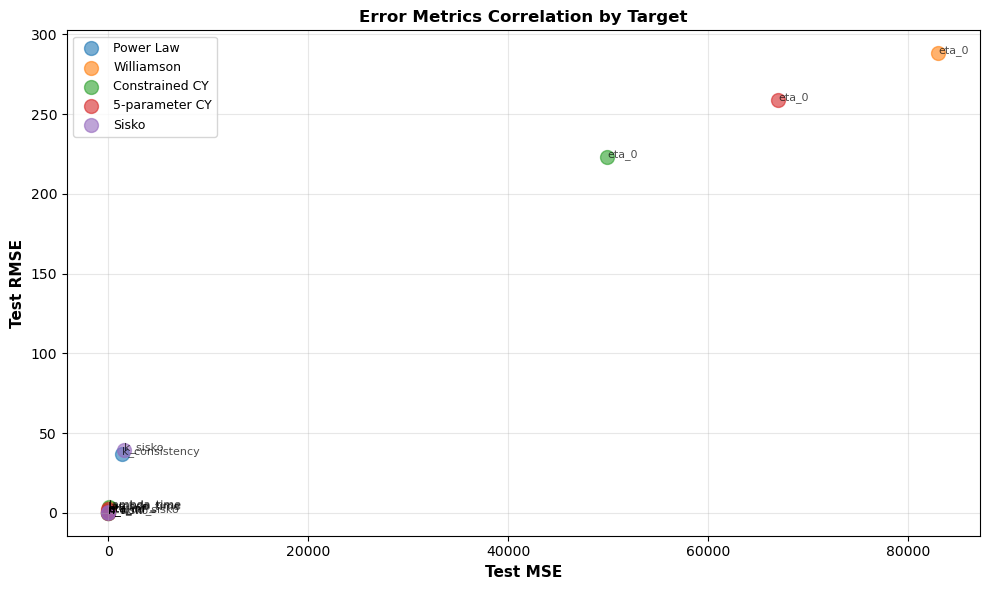

Chart 4 saved: ../data/processed/xgboost_results/4_error_distribution.png


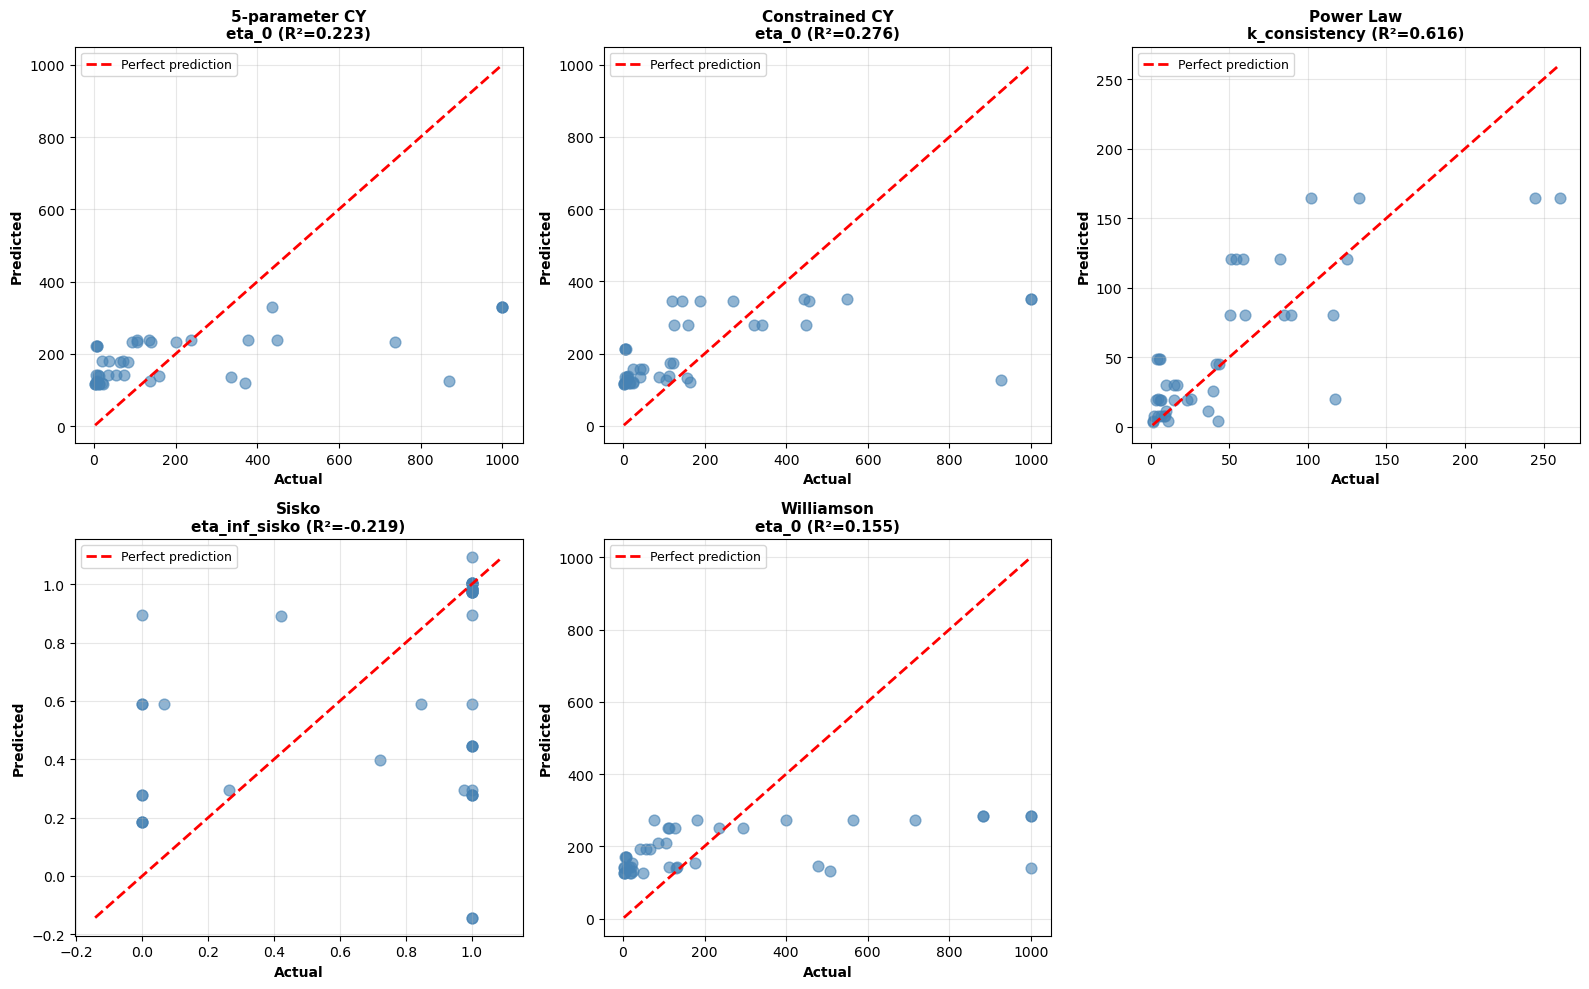

Chart 5 saved: ../data/processed/xgboost_results/5_predictions_vs_actual.png


In [21]:
# ===== 1. Model Comparison Charts (R², MSE, RMSE) =====
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_order = model_summary['model_name'].tolist()

# R² comparison
ax = axes[0]
colors = sns.color_palette("husl", len(model_order))
ax.barh(model_order, model_summary['test_r2'], color=colors)
ax.set_xlabel('Mean Test R²', fontsize=11, fontweight='bold')
ax.set_title('Model Performance: R²', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.0)
for i, v in enumerate(model_summary['test_r2']):
    ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

# MSE comparison
ax = axes[1]
ax.barh(model_order, model_summary['test_mse'], color=colors)
ax.set_xlabel('Mean Test MSE', fontsize=11, fontweight='bold')
ax.set_title('Model Performance: MSE', fontsize=12, fontweight='bold')
for i, v in enumerate(model_summary['test_mse']):
    ax.text(v + 100, i, f'{v:.1f}', va='center', fontsize=10)

# RMSE comparison
ax = axes[2]
ax.barh(model_order, model_summary['test_rmse'], color=colors)
ax.set_xlabel('Mean Test RMSE', fontsize=11, fontweight='bold')
ax.set_title('Model Performance: RMSE', fontsize=12, fontweight='bold')
for i, v in enumerate(model_summary['test_rmse']):
    ax.text(v + 2, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_PATH / '1_model_comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 1 saved: {RESULTS_PATH / '1_model_comparison_charts.png'}")

# ===== 2. Per-Target R² Heatmap =====
pivot_r2 = per_target.pivot_table(values='test_r2', index='target', columns='model_name', aggfunc='first')
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5, cbar_kws={'label': 'R²'}, ax=ax)
ax.set_title('Test R² by Target and Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Target Parameter', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH / '2_per_target_r2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 2 saved: {RESULTS_PATH / '2_per_target_r2_heatmap.png'}")

# ===== 3. Train vs Test R² for All Models =====
train_vs_test = model_summary.copy()
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(train_vs_test))
width = 0.35
ax.bar(x_pos - width/2, train_vs_test['train_r2'], width, label='Train R²', alpha=0.8, color='steelblue')
ax.bar(x_pos + width/2, train_vs_test['test_r2'], width, label='Test R²', alpha=0.8, color='coral')
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax.set_title('Train vs Test R² Performance', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(train_vs_test['model_name'], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / '3_train_vs_test_r2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 3 saved: {RESULTS_PATH / '3_train_vs_test_r2.png'}")

# ===== 4. Error Distribution by Model (MSE vs RMSE) =====
fig, ax = plt.subplots(figsize=(10, 6))
models = per_target['model_name'].unique()
for model in model_order:
    model_data = per_target[per_target['model_name'] == model]
    ax.scatter(model_data['test_mse'], model_data['test_rmse'], s=100, alpha=0.6, label=model)
    for idx, row in model_data.iterrows():
        ax.annotate(row['target'], (row['test_mse'], row['test_rmse']), fontsize=8, alpha=0.7)

ax.set_xlabel('Test MSE', fontsize=11, fontweight='bold')
ax.set_ylabel('Test RMSE', fontsize=11, fontweight='bold')
ax.set_title('Error Metrics Correlation by Target', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / '4_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 4 saved: {RESULTS_PATH / '4_error_distribution.png'}")

# ===== 5. Predictions vs Actual (Sample Targets) =====
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

sample_targets = predictions_df.groupby('model_name').first().reset_index().head(6)
for ax_idx, (_, row_info) in enumerate(sample_targets.iterrows()):
    ax = axes[ax_idx]
    model_name = row_info['model_name']
    target = row_info['target']
    
    target_preds = predictions_df[(predictions_df['model_name'] == model_name) & (predictions_df['target'] == target)]
    
    ax.scatter(target_preds['y_true'], target_preds['y_pred'], s=60, alpha=0.6, color='steelblue')
    
    # Perfect prediction line
    all_vals = np.concatenate([target_preds['y_true'].values, target_preds['y_pred'].values])
    lim = [all_vals.min(), all_vals.max()]
    ax.plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction')
    
    r2 = per_target[(per_target['model_name'] == model_name) & (per_target['target'] == target)]['test_r2'].values[0]
    ax.set_xlabel('Actual', fontsize=10, fontweight='bold')
    ax.set_ylabel('Predicted', fontsize=10, fontweight='bold')
    ax.set_title(f'{model_name}\n{target} (R²={r2:.3f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
if len(sample_targets) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_PATH / '5_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 5 saved: {RESULTS_PATH / '5_predictions_vs_actual.png'}")

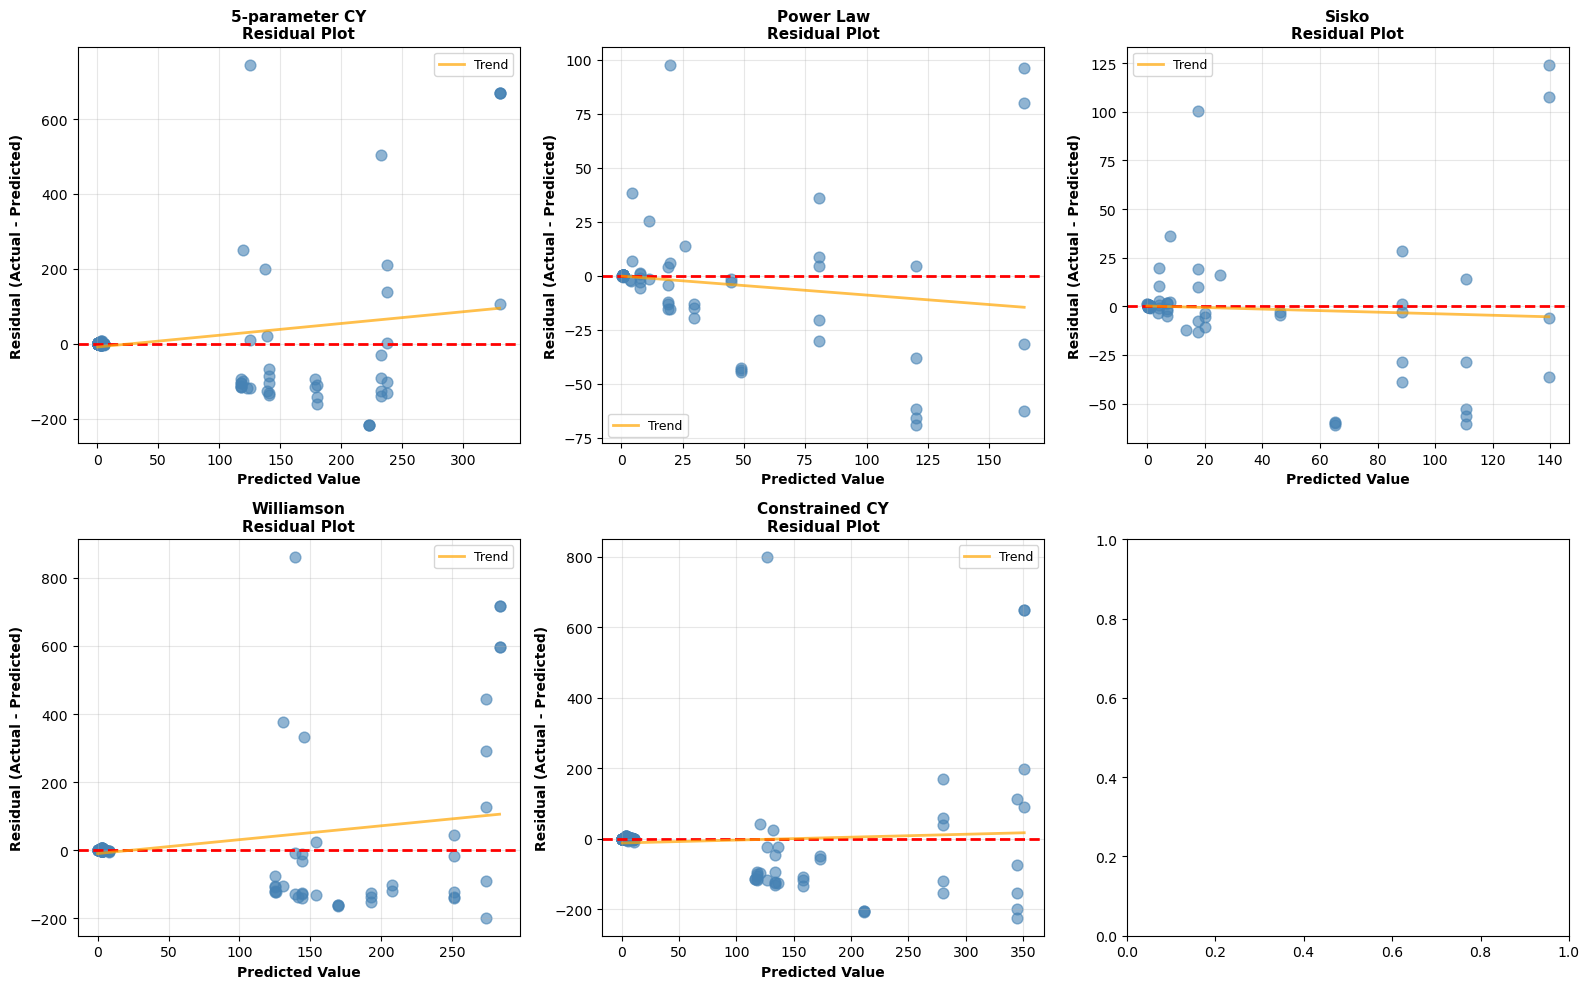

Chart 6 saved: ../data/processed/xgboost_results/6_residual_plots.png


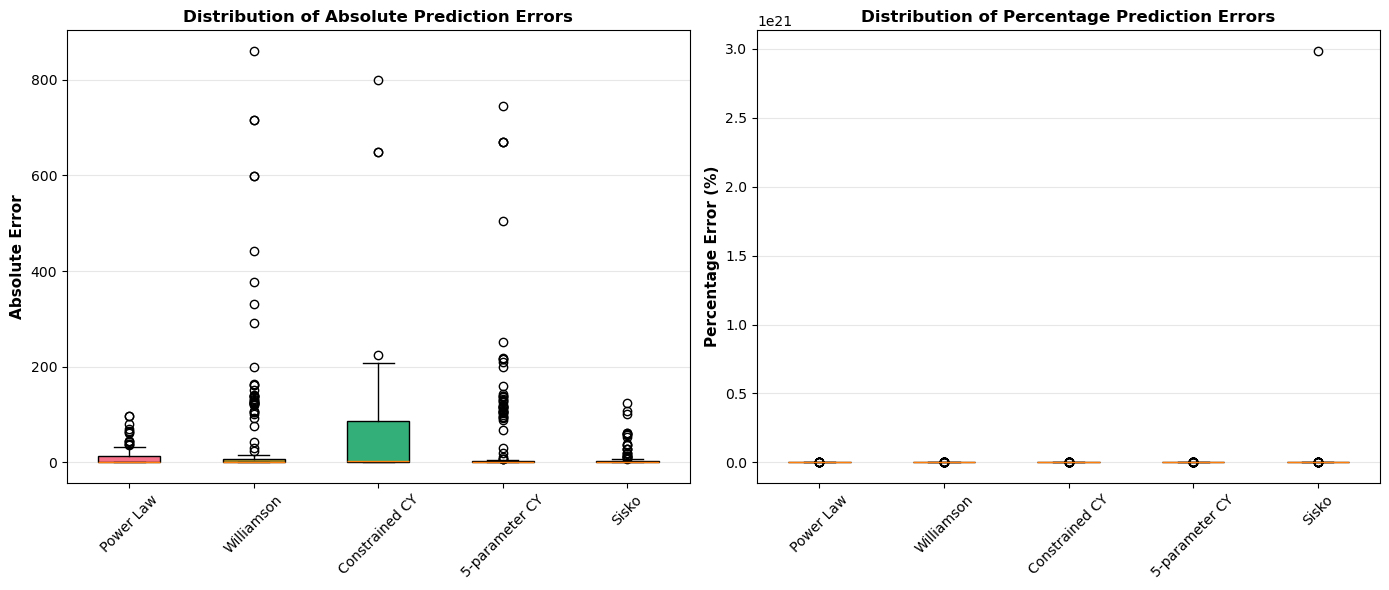

Chart 7 saved: ../data/processed/xgboost_results/7_error_statistics.png


In [22]:
# ===== 6. Residuals and Prediction Errors =====
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for model_idx, (model_key, display_name) in enumerate(MODEL_SPECS):
    ax = axes[model_idx]
    model_preds = predictions_df[predictions_df['model_name'] == display_name]
    
    residuals = model_preds['y_true'] - model_preds['y_pred']
    pred_vals = model_preds['y_pred']
    
    ax.scatter(pred_vals, residuals, s=60, alpha=0.6, color='steelblue')
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    
    # Add trend line
    z = np.polyfit(pred_vals, residuals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(pred_vals.min(), pred_vals.max(), 100)
    ax.plot(x_line, p(x_line), 'orange', linewidth=2, alpha=0.7, label='Trend')
    
    ax.set_xlabel('Predicted Value', fontsize=10, fontweight='bold')
    ax.set_ylabel('Residual (Actual - Predicted)', fontsize=10, fontweight='bold')
    ax.set_title(f'{display_name}\nResidual Plot', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_PATH / '6_residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 6 saved: {RESULTS_PATH / '6_residual_plots.png'}")

# ===== 7. Error Statistics by Model (Box Plot) =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute errors
ax = axes[0]
error_data = []
model_labels = []
for model_name in model_order:
    model_preds = predictions_df[predictions_df['model_name'] == model_name]
    abs_errors = np.abs(model_preds['y_true'] - model_preds['y_pred'])
    error_data.append(abs_errors)
    model_labels.append(model_name)

bp = ax.boxplot(error_data, labels=model_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], sns.color_palette("husl", len(model_order))):
    patch.set_facecolor(color)
ax.set_ylabel('Absolute Error', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Absolute Prediction Errors', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Percentage errors
ax = axes[1]
pct_error_data = []
for model_name in model_order:
    model_preds = predictions_df[predictions_df['model_name'] == model_name]
    pct_errors = 100 * np.abs(model_preds['y_true'] - model_preds['y_pred']) / np.abs(model_preds['y_true'])
    pct_error_data.append(pct_errors[np.isfinite(pct_errors)])
    
bp = ax.boxplot(pct_error_data, labels=model_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], sns.color_palette("husl", len(model_order))):
    patch.set_facecolor(color)
ax.set_ylabel('Percentage Error (%)', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Percentage Prediction Errors', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_PATH / '7_error_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 7 saved: {RESULTS_PATH / '7_error_statistics.png'}")

## Summary

**Workflow Complete!** This notebook provides a complete, reproducible pipeline for XGBoost model comparison across five rheology formulations with comprehensive visualizations.

### Key Results:
- All 5 models evaluated on the same train/test split
- Optuna hyperparameter tuning with ~10 trials per target
- Clean comparison tables sorted by performance
- Metrics: R², MSE, RMSE

### Files Generated:

**Data & Results:**
- `xgboost_model_summary.csv`: Model-level mean metrics
- `xgboost_per_target_results.csv`: Target-level metrics
- `xgboost_test_predictions.csv`: Test set predictions

**Physics Model Visualizations:**
- `physics_model_fits.png`: Fitted vs actual viscosity curves for each rheology model

**ML Model Visualizations:**
- `1_model_comparison_charts.png`: R², MSE, RMSE comparison across models
- `2_per_target_r2_heatmap.png`: Target-specific performance heatmap
- `3_train_vs_test_r2.png`: Train/test generalization analysis
- `4_error_distribution.png`: MSE vs RMSE scatter plot by target
- `5_predictions_vs_actual.png`: Sample predictions vs actual values
- `6_residual_plots.png`: Residual analysis for each model
- `7_error_statistics.png`: Box plots of absolute and percentage errors

### To Re-run with Different Parameters:
Edit the `CONFIG` dictionary in Section 2 and re-execute all cells.